# **Amazon Food&Grocery Sentiment Analysis Project**

## **1. Introduzione**

Questo progetto affronta un problema di Sentiment Analysis Binario per recensioni di Amazon Food and Grocery.
Dato un dataset contenente recensioni di Amazon Food and Grocery divise tra positive e negative andiamo a costruire modelli di Machine Learninig adatti alla predizione binaria affinché la macchina predica correttamente l'etichetta della recensione descritta come positiva o negativa.
In totale sono stati sperimentati e usati 4 modelli per effettuare training, test e validation sui dati e relative analisi dei risultati partendo da un modello di base quale la Regressione Logistica.

### **Regressione Logistica come modello di base**

La Regressione Logistica per predizione binaria è stata usata come modello di base data la sua semplicità, efficienza ed efficacia nelle predizioni di questo tipo. Questo modello ci permette inoltre di produrre risultati in modo estremamente meno oneroso rispetto agli altri modelli adottati, avendo così un ottimo punto di comparazione per gli altri modelli.

### **Reti Neurali Ricorrenti**

Il clue dello sviluppo del progetto è nelle Reti Neurali Ricorrenti (RNN), più precisamente Reti Neurali Ricorrenti con layer Bidirezionali (BRNN). Queste Reti Neurali permettono alla macchina di mantenere uno stato particolare inerente al contesto facendo si che si possa avere un valore aggiunto nella comprensione totale della recensione in analisi.
In particolare sono state sviluppate due Reti Neurali Ricorrenti con layer Bidirezionali, la prima BRNN usa una tokenizzazione basilare ed un layer di embedding trainable, la seconda BRNN usa una tokenizzazione ad hoc per il layer di embedding pre trainato Glove, entrambi i costrutti e i concetti sono trattati più avanti nel dettaglio.

### **Transformers**

Lo stato dell'arte attuale per modelli di Machine Learning è descritta dai Transformers, modelli caratterizzati da self-attention, alta parallelizzazione e processamento della totalitarietà della sequenza riseptto alle analisi parola per parola effettuate dalle RNN.
In particolare è stata sviluppata una soluzione compatta basata sul Transformer "bert-base-uncased-SST-2" ovvero un modello pre-addestrato con iperparametri pre-regolato.

### **WorkFlow del Progetto**

Sotto un ottica di WorkFlow il progetto segue le seguenti fasi:
1. Caricamento e divisione del Dataset.
2. Strategie di preprocessamento dei dati, creazione del tokenizzatore, inizializzazione e caricamento dei layer di embedding.
3. Sviluppo del modello di Regressione Logistica, usata come modello di confronto, e relativa valutazione dei risultati.
4. Sviluppo dei modelli BRNN con LSTM con differenti configurazioni e valutazione dei risultati.
5. Sviluppo del modello basato su Transformers e valutazione dei risultati.
6. Costruzione di un dataset con recensioni proprietarie, inferenza e valutazione dei risultati.


---



In [ ]:
%env XLA_FLAGS=--xla_gpu_cuda_data_dir=/usr/lib/cuda
import os
import warnings

# Nasconde i warning Python
warnings.filterwarnings("ignore")

# Nasconde i log di TensorFlow
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"  # 0 = tutto, 3 = solo errori critici

# Nasconde gli stdout di Transformers/HuggingFace
from transformers.utils import logging as hf_logging
hf_logging.set_verbosity_error()

# Nasconde gli stdout di tqdm
import logging
logging.getLogger("transformers").setLevel(logging.ERROR)

from transformers import BertTokenizer, TFBertForSequenceClassification
import tensorflow as tf
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, log_loss
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import StratifiedKFold
from tensorflow.keras.models import load_model
import pickle
import re
import string
from tensorflow.keras import layers, Model
from tensorflow.keras.preprocessing import sequence
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
import math
from tensorflow.keras import layers, callbacks
from tensorflow.keras import layers, models, preprocessing
import keras_tuner as kt

## **2. Caricamento e Divisione del Dataset**

Caricamento del Dataset attraverso l'uso della funzione `text_dataset_from_directory` per i modelli basati su BRNN e Transformers.
Divisione del Dataset in 70% TrainingSet, 15% TestSet e 15% ValidationSet, ottimizzazione del caricamento tramite `.cache()` e pre-caricamento dei batch tramite `.prefetch(buffer_size=AUTOTUNE)`

In [ ]:
DATASET_DIR = "/home/reliq/Documents/ML/[24-25]/Progetto/Grocery_and_Gourmet_FoodBinary"
def load_dataset(
    data_dir, batch_size=32, validation_split=0.15, test_split=0.15, seed=42
):
    AUTOTUNE = tf.data.AUTOTUNE #Uso ottimizzato della cache per i vari batch

    # Training dataset
    train_ds = preprocessing.text_dataset_from_directory(
        data_dir,
        batch_size=batch_size,
        validation_split=validation_split + test_split,
        subset="training",
        seed=seed,
    )
    train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)

    # Val e test set
    val_and_test_ds = preprocessing.text_dataset_from_directory(
        data_dir,
        batch_size=batch_size,
        validation_split=validation_split + test_split,
        subset="validation",
        seed=seed,
    )
   
    # Split
    val_size = math.floor(
        (validation_split / (validation_split + test_split)) * len(val_and_test_ds)
    )

    #print(validation_split + test_split, val_size)

    val_ds = val_and_test_ds.take(val_size)
    val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

    test_ds = val_and_test_ds.skip(val_size)
    test_ds = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

    return train_ds, val_ds, test_ds


# Load dataset in training (70%), validation (15%), and test (15%) sets
train_ds, val_ds, test_ds = load_dataset(DATASET_DIR)

# Conta il numero di elementi in ogni dataset
def count_elements(dataset):
    #return sum(1 for _ in dataset.unbatch())
    return sum(1 for _ in dataset)


num_train = count_elements(train_ds)
num_val = count_elements(val_ds)
num_test = count_elements(test_ds)


def load_full_dataset():
    # Carica tutto il dataset senza suddivisione
    full_ds = tf.keras.preprocessing.text_dataset_from_directory(
        DATASET_DIR,
        batch_size=None,  # Restituisce un dataset non batchato
        shuffle=False      # Ordine fisso per mantenere corrispondenza testo/etichetta
    )

    # Estrai testi e label come liste
    texts, labels = extract_texts_and_labels_for_distilbert(full_ds)

    return list(zip(texts, labels)) 


def extract_text_and_labels(dataset):
    texts = []
    labels = []
    for text, label in dataset:
        texts.extend([t.numpy().decode("utf-8") for t in text])
        labels.extend(label.numpy())
    return texts, labels

def extract_texts_and_labels_for_distilbert(dataset):
    texts = []
    labels = []
    for text_batch, label_batch in dataset.unbatch():
        text = text_batch.numpy()
        if isinstance(text, bytes):
            text = text.decode("utf-8")
        texts.append(text)
        labels.append(label_batch.numpy())
    return texts, labels


In [3]:

def plot_training_metrics(history):
    acc = history.history.get("accuracy", [])
    val_acc = history.history.get("val_accuracy", [])
    loss = history.history.get("loss", [])
    val_loss = history.history.get("val_loss", [])

    epochs = range(len(acc))

    plt.figure(figsize=(10, 6))
    plt.plot(epochs, acc, 'o-', label='accuracy')
    plt.plot(epochs, loss, 'o-', label='loss')
    plt.plot(epochs, val_acc, 'o-', label='val_accuracy')
    plt.plot(epochs, val_loss, 'o-', label='val_loss')
    
    plt.title('Training Metrics Over Epochs')
    plt.xlabel('Epochs')
    plt.ylabel('Value')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


def evaluate_lstm_model(model, test_ds, threshold=0.5):
    # Estrae testi ed etichette
    texts, labels = extract_texts_and_labels_for_distilbert(test_ds)

    # Crea dataset
    input_ds = tf.data.Dataset.from_tensor_slices(texts).batch(32)

    # Predizioni
    probs = model.predict(input_ds).flatten()
    preds = (probs > threshold).astype(int)

    print("\nClassification Report:\n")
    print(classification_report(labels, preds, target_names=["NEGATIVE", "POSITIVE"]))

    # Confusion Matrix
    cm = confusion_matrix(labels, preds)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=["NEGATIVE", "POSITIVE"],
                yticklabels=["NEGATIVE", "POSITIVE"])
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title("Confusion Matrix")
    plt.tight_layout()
    plt.show()

    # Accuracy
    acc = accuracy_score(labels, preds)
    print(f"\nFinal Accuracy: {acc:.4f}")



def evaluate_model_predictions(model, tokenizer, texts, labels, max_length=256, batch_size=32):
    # Tokenizzazione
    encodings = tokenizer(
        texts,
        truncation=True,
        padding=True,
        max_length=max_length,
        return_tensors='tf'
    )

    # Dataset TensorFlow per inferenza
    infer_ds = tf.data.Dataset.from_tensor_slices({
        "input_ids": encodings["input_ids"],
        "attention_mask": encodings["attention_mask"]
    }).batch(batch_size)

    # Inferenza
    logits = model.predict(infer_ds).logits
    probs = tf.nn.softmax(logits, axis=1).numpy()
    preds = np.argmax(probs, axis=1)

    # Report
    print("\nClassification Report:\n")
    print(classification_report(labels, preds, target_names=["NEGATIVE", "POSITIVE"]))

    # Confusion Matrix
    cm = confusion_matrix(labels, preds)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=["NEGATIVE", "POSITIVE"],
                yticklabels=["NEGATIVE", "POSITIVE"])
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title("Confusion Matrix")
    plt.tight_layout()
    plt.show()

    # Accuracy
    acc = accuracy_score(labels, preds)
    print(f"\nFinal Accuracy: {acc:.4f}")
    

## **3. Preprocessing e Vettorizzazione**
Preprocessamento e tokenizzazione sono passaggi indispensabili, permettono di lavorare il testo grezzo delle recensioni in formato numerico comprensbile alla macchina.

Il nostro obiettivo è testare due approcci, ciascuno progettato per utilizzare un diverso tipo di layer di embedding. 
Insieme alla pre-elaborazione e alla tokenizzazione, definiamo anche delle funzioni per costruire i layer iniziali di un modello riutilizzabile, inclusi i layer di input fino all'embedding, cercando di mantenere il codice il più modulare possibile.

### **Vectorizer e Trainable Embedding Layer**

Il primo approccio si concentra su un preprocessamento semplice per in cui tutti i caratteri maiuscoli vengono portati minuscoli, sono rimossi eventuali caratteri speciali e spazi ripetuti oltre a spazi iniziali e finali non utili all'addestramento del modello. 

Creiamo quindi il layer di vettorizzazione `layers.TextVectorization` tramite il quale viene automaticamente costurito un vocabolario contenente i termini più frequenti, fino ad un massimo di `max_tokens`, convertiti in numeri unici per ogni termine per poi troncare o introdurre padding affinché le sequenze abbiano stessa lunghezza.

A questo layer di vettorizzazione aggiungiamo un layer di embedding addestrabile `layers.Embedding` che ci permette di convertire i numeri interi prodotti dalla vettorizzazione in vettori numerici densi ovvero un insieme di valori numerici reali che contengono il significato semantico delle parole.
Essendo questo layer trainable avremo che i vettori numerici vengono appresi dal layer epoca per epoca ovvero il modello andrà ad aggiornare i valori all'intenro di ciascun vettore andando a creare una rappresentazione finale personalizzata che possa minimizzare l'errore finale.

### **Tokenizer e Glove Embedding**

Il secondo approccio si conentra su un preprocessamento più complesso in cui vengono rimossi numeri e caratteri non alfabetici ad eccezione della punteggiatura che nel caso di ripetizioni viene isolata e valorizzata, aggiungnendo valore alla semantica, inoltre vengono espanse le contrazioni affinché tutte le parole abbreviate (es:`can't` -> `cannot`) possano ricevere un'opportua rappresentazione.


Viene quindi utilizzato un Tokenizzatore manuale che divide le sequenze in token tramite `.split()` per poi confrontare ogni token con il contenuto del vocabolario precedentemente creato manualmente e se presente viene convertita in numero. 

Applichiamo quindi il layer di Embedding pre addestrato Glove, per la precisione la versione di Glove `glove.840B.300d`.
Essendo questo layer pre addestrato il preprocessamento e la relativa tokenizzazione devono essere affini con ciò che il layer di embedding comprende, per poter verificare quindi la coverage totale usiamo la funzione `calculate_embedding_coverage` dove contiamo quanti dei nostri token contenuti nel vocabolario creato sono presenti nel layer di embedding, ottenendo 93,21% di coverage.



In [4]:
# Preprocess base
def preprocess_text(text):
    text = tf.strings.lower(text)  # Conversione in minuscolo
    text = tf.strings.regex_replace(text, r"\W", " ")  # Rimozione di caratteri speciali
    text = tf.strings.regex_replace(text, r"\s+", " ")  # Rimozione di spazi multipli
    text = tf.strings.strip(text)  # Rimozione di spazi iniziali e finali
    return text


def create_vectorizer(max_tokens, max_seq_length, preprocess=preprocess_text):
    vectorizer = layers.TextVectorization(
        max_tokens=max_tokens,
        output_mode="int",
        output_sequence_length=max_seq_length,
        standardize=preprocess
    )
    return vectorizer


def init_train_emb_model(
    max_tokens, max_seq_length, embedding_dim, dropout_train_emb, preprocess=preprocess_text
):
    vectorizer = create_vectorizer(max_tokens, max_seq_length, preprocess)
    train_text = train_ds.map(lambda x, y: x)
    vectorizer.adapt(train_text)

    model = models.Sequential()
    model.add(vectorizer)
    model.add(layers.Embedding(input_dim=max_tokens, output_dim= embedding_dim))
    model.add(layers.Dropout(dropout_train_emb))

    return model

# Contrazioni comuni inglesi
CONTRACTIONS = {
    "can't": "cannot", "won't": "will not", "don't": "do not", "doesn't": "does not",
    "i'm": "i am", "you're": "you are", "they're": "they are", "we're": "we are",
    "isn't": "is not", "aren't": "are not", "wasn't": "was not", "weren't": "were not",
    "i've": "i have", "you've": "you have", "they've": "they have", "we've": "we have",
    "i'll": "i will", "you'll": "you will", "they'll": "they will", "we'll": "we will",
    "it's": "it is", "that's": "that is", "what's": "what is", "there's": "there is"
}

def expand_contractions(text):
    pattern = re.compile(r'\b(' + '|'.join(CONTRACTIONS.keys()) + r')\b')
    return pattern.sub(lambda x: CONTRACTIONS[x.group()], text)

def preprocess_text_glove(text):
    text = text.lower()
    text = expand_contractions(text)

    # Rimuove URL e utenti
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    text = re.sub(r'@\w+', '', text)

    # Rimuove numeri
    text = re.sub(r'\d+', '', text)

    # Isola punteggiatura utile
    text = re.sub(r'([!?\.]){2,}', r'\1', text)  # !!! -> !
    text = re.sub(f'([{re.escape(string.punctuation)}])', r' \1 ', text)

    # Rimuove simboli extra non alfabetici
    text = re.sub(r'[^\w\s!?\.]', '', text)

    # Normalizza spazi
    text = re.sub(r'\s+', ' ', text).strip()

    return text

In [5]:
MAX_VOCAB_SIZE = 10000
GLOVE_PATH = "glove.840B.300d.txt"
MAX_LENGTH = 50
MAX_TOKENS = [10000, 20000, 40000]
DEFAULT_MAX_TOKENS = MAX_TOKENS[1]
EMBEDDING_DIM = 300


def create_vocab(texts, max_vocab_size=20000, oov_token="<OOV>"):
    word_count = {}
    for text in texts:
        words = preprocess_text_glove(text).split()
        for word in words:
            word_count[word] = word_count.get(word, 0) + 1

    # Ordina le parole per frequenza (dalla più frequente alla meno)
    sorted_words = sorted(word_count.items(), key=lambda x: x[1], reverse=True)
    
    # Seleziona solo le top max_vocab_size parole
    limited_words = sorted_words[:max_vocab_size]

    word_index = {oov_token: 1}  # OOV = 1, 0 riservato al padding
    index = 2
    for word, _ in limited_words:
        word_index[word] = index
        index += 1

    return word_index


#Creazione matrice embedding GloVe
def load_glove_embeddings(glove_path, word_index, embedding_dim):
    embeddings_index = {}
    with open(glove_path, "r", encoding="utf-8") as f:
        for line in f:
            values = line.strip().split()
            word = values[0]
            try:
                coefs = np.asarray(values[1:], dtype='float32')
            except ValueError:
                continue

            embeddings_index[word] = coefs
            
    embedding_matrix = np.zeros((len(word_index) + 1, embedding_dim))
    
    for word, index in word_index.items():
        embedding_vector = embeddings_index.get(word)
        if embedding_vector is not None:
            embedding_matrix[index] = embedding_vector

    return embedding_matrix

In [ ]:
#Funzione di tokenizzazione manuale per Glove
def texts_to_sequences(texts, word_index, oov_token="<OOV>"):
    sequences = []
    for text in texts:
        words = preprocess_text_glove(text).split()
        sequence = [word_index.get(word, word_index[oov_token]) for word in words]
        sequences.append(sequence)
    return sequences

raw_train_ds, raw_val_ds, raw_test_ds = load_dataset(DATASET_DIR)
train_texts, train_labels = extract_text_and_labels(raw_train_ds)
val_texts, val_labels = extract_text_and_labels(raw_val_ds)
test_texts, test_labels = extract_text_and_labels(raw_test_ds)

#Creazione vocabolario
word_index = create_vocab(train_texts)

#Padding
X_train_pad = pad_sequences( 
    texts_to_sequences(train_texts, word_index), 
    maxlen=MAX_LENGTH, 
    padding='post')

X_val_pad = pad_sequences(
    texts_to_sequences(val_texts, word_index),
    maxlen=MAX_LENGTH, 
    padding='post')

X_test_pad = pad_sequences(
    texts_to_sequences(test_texts, word_index),
    maxlen=MAX_LENGTH, 
    padding='post')


In [7]:
#Valutazione coverage Tokenizzazione Vocabolario ed Embedding Glove
def calculate_embedding_coverage(word_index, glove_path, embedding_dim=300):
    #Carico embeddings GloVe
    embeddings_index = {}
    with open(glove_path, "r", encoding="utf-8") as f:
        for line in f:
            values = line.strip().split()
            word = values[0]
            try:
                coefs = np.asarray(values[1:], dtype='float32')
            except ValueError:
                continue
            embeddings_index[word] = coefs

    # Contiamo quanti dei nostri token sono presenti negli embeddings
    total_tokens = len(word_index)  # Numero di token nel nostro vocabolario (word_index)
    matched_tokens = 0  # Conta i token presenti nel vocabolario GloVe

    for word in word_index:
        if word in embeddings_index:  # Controlla se il token è nel vocabolario GloVe
            matched_tokens += 1

    # Calcola la percentuale di corrispondenza
    coverage_percentage = (matched_tokens / total_tokens) * 100
    return coverage_percentage

coverage = calculate_embedding_coverage(word_index, GLOVE_PATH, embedding_dim=300)
print(f"Percentuale di corrispondenza con GloVe: {coverage:.2f}%")

Percentuale di corrispondenza con GloVe: 93.21%


## **4. Regressione Logistica**

Usiamo un modello di Regressione Logistica come baseline comparativa per gli altri modelli.
Questa soluzione compatta è stata sviluppata come sperimentazione e successivamente adottata cercando di massimizzare i risultati cambiando manualmente alcuni parametri.

Abbiamo un preprocessing dei dati basilare che converte tutto i termini in minuscolo, rimuove la punteggiatura e rimuove le stop-words come articoli e altri termini che non portano significato semantico singolarmente.

Come vettorizzatore usiamo `TF-IDF` che permette di pesare i termini presenti nella recensione in base a quanto queste siano distintive penalizzando le parole eccessivamente frequenti riducendo così l'overfitting su parole eccessivamente comuni.

Come solver per il modello di Regressione Logistica usiamo `Saga (Stochastic Average Gradient Agumented)`, ovvero una versione estesa del solver `Sag (Stochastic Average Gradient)` con un parametro C pari a 4.5, questo indica quanto i pesi debbano essere penalizzati e indirettamente il carattere di overfitting o underfitting del modello per valori eccessivamente alti o bassi.

L'unione di un modello di Regressione Logistica, una vettorizzazione TF-IDF e una regolarizzazione basata sulla Norma L2 ci permette di rendere il modello efficiente anche per testi brevi, permettendo di estrarre anche da pochi termini il significato semantico con stabilità del modello.


Osservando i risultati possiamo vedere che il modello presenta un'accuratezza delle predizioni pari a 91.65%, valore ottimo per un modello semplice come la Regressione Logistica, un valore di Logarithmic Loss (LogLoss) di circa 0.216 che ci indica la sicurezza del modello nelle predizioni e una funzione costo J di circa 0.4 che ci indica un funzionamento corretto nella regolarizzazione affinché non vi fosse overfitting. 

Grazie alla metrica F1-Score possiamo vedere come vi sia un ottimo equilibrio da Precision, che ci indica quanti falsi positivi sono verificati, e Recall, che ci indica quanti elementi realmente positivi il modello è riuscito a predirre correttamente.

Possiamo infine visualizzare la Matrice di Confusione per capire quante predizioni TruePositive o TrueNegative e quante FalsePositive o FalseNegative in modo quantitativo si sono verificate.



Validation Accuracy: 0.9165
Validation Log Loss: 0.21555282763240832
Validation Cost Function J: 0.397742839837467
Validation Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.93      0.92      2986
           1       0.93      0.90      0.92      3014

    accuracy                           0.92      6000
   macro avg       0.92      0.92      0.92      6000
weighted avg       0.92      0.92      0.92      6000

Test Accuracy: 0.925
Test Log Loss: 0.19465905728436633
Test Cost Function J: 0.376849069489425
Test Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.93      0.93      3011
           1       0.93      0.92      0.92      2989

    accuracy                           0.93      6000
   macro avg       0.93      0.92      0.92      6000
weighted avg       0.93      0.93      0.92      6000



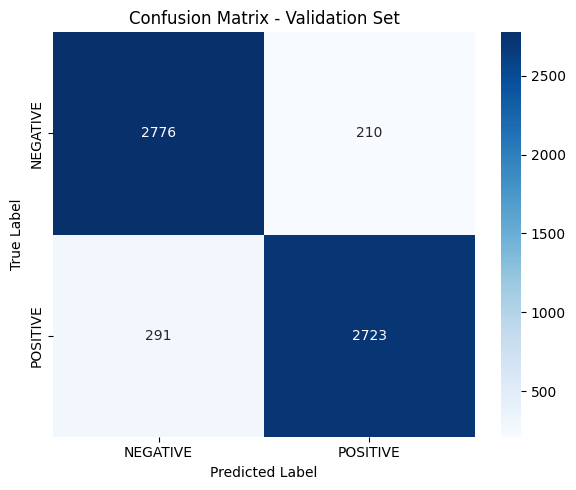

In [8]:
#Regressione Logistica

# Calcolo della funzione costo J con regolarizzazione L2
def calculate_cost_function_J(log_loss_value, model, C, n_samples):
    weights = model.coef_
    l2_norm = np.sum(weights**2)
    lambda_reg = 1 / C
    J = log_loss_value + (lambda_reg / (2 * n_samples)) * l2_norm
    return J

def preprocess_text(text):
    stop_words = set(stopwords.words('english'))
    words = word_tokenize(text.lower())  # Tokenizza e converte in minuscolo
    filtered_words = [word for word in words if word.isalnum() and word not in stop_words]
    return " ".join(filtered_words)

# Calcola la log loss
def calculate_log_loss(y_true, y_pred):
    return log_loss(y_true, y_pred)

#Caricamento dati e labeling
def load_data(data_dir):
    texts = []
    labels = []
    for label in [0, 1]:  # 0 = negativo, 1 = positivo
        folder = os.path.join(data_dir, str(label))
        for filename in os.listdir(folder):
            if filename.endswith(".txt"):
                with open(os.path.join(folder, filename), 'r', encoding='utf-8') as file:
                    text = file.read()
                    texts.append(text)
                    labels.append(label)
    return texts, labels

data_dir = '/home/reliq/Documents/ML/[24-25]/Progetto/Grocery_and_Gourmet_FoodBinary'

texts, labels = load_data(data_dir)

X_train, X_temp, y_train, y_temp = train_test_split(texts, labels, test_size=0.30, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42)


# Creazione della rappresentazione TF-IDF dei dati testuali
vectorizer = TfidfVectorizer(max_features=5000)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_val_tfidf = vectorizer.transform(X_val)
X_test_tfidf = vectorizer.transform(X_test)


# Creazione del modello di regressione logistica
model = LogisticRegression(
    penalty="l2",                 # Tipo di penalizzazione (default: "l2")
    dual=False,                   # Risolve il problema duale (default: False, usato solo con 'l2' e solver 'liblinear')
    tol=0.0001,                   # Tolleranza per il criterio di arresto (default: 0.0001)
    C=4.5,                        # Inverso della forza della regolarizzazione (default: 1.0)
    fit_intercept=True,           # Calcola l'intercetta (default: True)
    #intercept_scaling=1,          # Usato solo se solver='liblinear'
    class_weight=None,            # Pesi delle classi (default: None)
    random_state=42,            # Seed per la riproducibilità (default: None)
    solver="saga",               # Algoritmo di ottimizzazione (default: "lbfgs")
    max_iter=1000,                 # Numero massimo di iterazioni (default: 100)
    #multi_class="auto",           # Strategia per problemi multiclass (default: "auto")
    verbose=0,                    # Livello di verbosità (default: 0)
    warm_start=False,             # Usa la soluzione precedente come inizio (default: False)
    n_jobs=None,                  # Numero di core per il calcolo parallelo (default: None)
    l1_ratio=None                 # Rapporto L1/L2 per elasticnet (default: None, usato solo con solver='saga')
)


#Training
model.fit(X_train_tfidf, y_train)

# Predizioni sul validation set
y_val_pred = model.predict(X_val_tfidf)
y_val_pred_prob = model.predict_proba(X_val_tfidf) 

val_loss = calculate_log_loss(y_val, y_val_pred_prob)

val_accuracy = accuracy_score(y_val, y_val_pred)
val_report = classification_report(y_val, y_val_pred)

J_val = calculate_cost_function_J(val_loss, model, C=4.5, n_samples=len(y_val))

print(f"Validation Accuracy: {val_accuracy}")
print(f"Validation Log Loss: {val_loss}")
print(f"Validation Cost Function J: {J_val}")
print("Validation Classification Report:")
print(val_report)

# Predizioni sul test set
y_test_pred = model.predict(X_test_tfidf)
y_test_pred_prob = model.predict_proba(X_test_tfidf)

test_accuracy = accuracy_score(y_test, y_test_pred)
test_report = classification_report(y_test, y_test_pred)

test_loss = calculate_log_loss(y_test, y_test_pred_prob)

J_test = calculate_cost_function_J(test_loss, model, C=4.5, n_samples=len(y_test))

print(f"Test Accuracy: {test_accuracy}")
print(f"Test Log Loss: {test_loss}")
print(f"Test Cost Function J: {J_test}")
print("Test Classification Report:")
print(test_report)

cm_val = confusion_matrix(y_val, y_val_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_val, annot=True, fmt="d", cmap="Blues",
            xticklabels=["NEGATIVE", "POSITIVE"],
            yticklabels=["NEGATIVE", "POSITIVE"])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Validation Set")
plt.tight_layout()
plt.show()

## **5. Bidirectional Recurrent Neural Network**

Tutti i modelli di Reti Neurali Ricorrenti con layer Bidirezionali (BRNN) usati sono basati sulla stessa costruzione e sullo stesso tuning di iperparametri descritto nel codice sottostante.

### **Bidirectional LSTM Layers**

I modelli sono caratterizzati da due primi layer bidirezionali LSTM che permettono di catturare il contesto processando la sequenza data sia in avanti che indietro. Affinché la maggior parte delle informazioni sia tramandata ai layer successivi entrambi i layer bidirezionali restituiscono l'intera sequenza, e non uno stato nascosto finale, questo permette di preservare le informazioni raccolte. 

Per far si che venga restituita l'intera sequenza e non uno stato nascosto finale usiamo `GlobalAveragePooling1D()` che ci permette di calcolare la media degli stati nascosti per ogni stato temporale condensando l'informazione temporale dell'intera sequenza.

Inoltre il secondo layer bidirezionale possiede la metà delle unità rispetto al primo mantenendo un andamento decrescente che ci permette di ridurre la complessità andando sempre più in profondità con l'archittettura.

### **Layer Densi**

Successivamente ai layer bidirezionali abbiamo quattro layer densi con un numero di unità lstm che vanno a dimezzarsi layer per layer diminuendo così la complessità fino ad arrivare all'ultimo layer composto da una sola unità per la predizione finale binaria.

### **Dropout**

Tutti i layer, sia bidirezionali che densi, sono affetti da Dropout, ciò ci permette di disattivare parte dei neuroni di ogni layer durante l'addestramento evitando così un potenziale overfitting migliorando le capacità generalizzanti del modello.

### **Hyperparameter Tuning**

Affinché i modelli possano essere il più ottimizzati possibile eseguiamo il Tuning degli Iperparametri su alcuni valori con un approccio `RandomSearch` tramite `KerasTuner`. Durante la fase di trainig il modello proverà vari valori di alcuni iperparametri per poi valutare le prestazioni a training concluso e iniziarne uno nuovo con nuovi valori da valutare, quando tutti i trial di training si concludono il tuning darà in output le coppie di valori che hanno raggiunto le prestazioni migliori durante i trial.

Gli iperparametri ottimizzati per entrambi i modelli basati su BRNN sono:
- Unità LSTM
- Dropout presente nei layer bidirezionali
- Dropout presente nei layer densi

Il numero di unità LSTM è ciò che compone sia i layer bidireizonali che quelli densi, il valore trovato si andrà ad estendere quindi a cascata su tutti i layer.

L'approcio di ricerca RandomSearch permette al modello di trovare alcuni iperparametri ottimi locali nel dominio valutato, questo perché un valore ottimo globale sarebbe computazionalmente eccessivamente oneroso da trovare, applichiamo quindi un compromesso tra onerosità e valori ottimi globali.



In [9]:
MAX_LENGTH = 50
MAX_TOKENS = [10000, 20000, 40000]
DEFAULT_MAX_TOKENS = MAX_TOKENS[1]
EMBED_DIM = 200

def build_model(model, hp):

    # Tuning parametri LSTM
    lstm_units = hp.Int("lstm_units", min_value=128, max_value=256, step=32)
    dropout_bid_lstm = hp.Float("dropout_bid_lstm", min_value=0.1, max_value=0.5, step=0.1)
    #recurrent_dropout = hp.Float("recurrent_dropout", min_value=0.0, max_value=0.5, step=0.1)
    dropout_dense = hp.Float("dropout_dense", min_value=0.1, max_value=0.5, step=0.1)

    model.add(layers.Bidirectional(layers.LSTM(
        units=lstm_units,
        dropout=dropout_bid_lstm,
        #recurrent_dropout=recurrent_dropout,
        return_sequences=True
    )))
    model.add(layers.Bidirectional(layers.LSTM(
        units=lstm_units // 2,
        dropout=dropout_bid_lstm,
        #recurrent_dropout=recurrent_dropout,
        return_sequences=True
    )))

    # Global average pooling
    model.add(layers.GlobalAveragePooling1D())

    model.add(layers.Dense(lstm_units // 2, activation='relu'))
    model.add(layers.Dropout(dropout_dense))
    model.add(layers.Dense(lstm_units // 4, activation="relu"))
    model.add(layers.Dropout(dropout_dense))
    model.add(layers.Dense(lstm_units // 16, activation="relu"))
    model.add(layers.Dropout(dropout_dense))
    model.add(layers.Dense(1, activation='sigmoid'))

    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return model

def build_model_with_glove(hp, embedding_layer):
    model = tf.keras.Sequential()

    # Aggiunge Embedding pre-addestrato
    model.add(layers.Embedding(input_dim=embedding_layer.shape[0],
                               output_dim=embedding_layer.shape[1],
                               weights=[embedding_layer],
                               input_length=MAX_LENGTH,
                               trainable=False))
    model= build_model(model, hp)
    return model

# Tuner personalizzato
class SentimentAnalysisTuner:
    def __init__(self, build, project_name, dir="tuner_logs", objective="val_accuracy", max_trials=15, seed=42, debug=False):
        self.build = build
        self.project_name = project_name
        self.dir = dir
        self.objective = objective
        self.max_trials = max_trials
        self.seed = seed
        self.debug = debug
        self.tuner = None
        self.best_model = None
        self.history = None

    def search(self, train_ds, val_ds, epochs=30, patience=4):
        self.tuner = kt.RandomSearch(
            self.build,
            objective=self.objective,
            max_trials=self.max_trials,
            overwrite=True,
            directory=self.dir,
            project_name=self.project_name,
            seed=self.seed
        )

        self.tuner.search(
            train_ds,
            validation_data=val_ds,
            epochs=epochs,
            callbacks=[callbacks.EarlyStopping(patience=patience)],
            verbose=2
        )

    def fit(self, train_ds, val_ds, epochs=30, patience=4):
        best_hp = self.tuner.get_best_hyperparameters(1)[0]
        self.best_model = self.tuner.hypermodel.build(best_hp)
        self.history = self.best_model.fit(
            train_ds,
            validation_data=val_ds,
            epochs=epochs,
            callbacks=[callbacks.EarlyStopping(patience=patience)],
            verbose=1
        )
        return self.history

    def evaluate(self, test_ds):
        return self.best_model.evaluate(test_ds)





## **6. Bidirectional LSTM with Trainable Embedding**

Il codice seguente mostra le chiamate all'inizializzaizone e alla costruzione del modello di Rete Neurale Ricorrente con Layer Bidirezionali e con Embedding Addestrabile.
Oltre alla costruzione e al tuning modulare creati per tutti i modelli BRNN in questo modello in particolare possiamo trovare iperparametri aggiuntivi sui quali facciamo tuning quali:
- Dimensione del vocabolario
- Dropout presente nel layer di embedding addestrabile

Osservando i risultati possiamo notare che il valore più alto di accuratezza sul validation set trovato tramite tuning è 91.82% con i valori riportati sotto la dicitura "Migliori Iperparametri Trovati".
Il modello presenta un recall più elevato per la classe negativa e una precision più alta per la classe positiva, riesce quindi a identificare leggermente meglio le recensioni negative, mentre quando predice “positivo” sbaglia meno. Complessivamente, l’equilibrio tra recall e precision su entrambe le classi è confermato dalle F1-score simili, senza quindi evidenti sbilanciamenti nelle predizioni.

Possiamo visualizzare la Matrice di Confusione per capire quante predizioni TruePositive o TrueNegative e quante FalsePositive o FalseNegative in modo quantitativo si sono verificate, e infine il grafico mostrante l'evoluzione di accuracy, loss, value accuracy e value loss durante le varie epoche.

Trial 15 Complete [00h 04m 10s]
val_accuracy: 0.9144384860992432

Best val_accuracy So Far: 0.9182820916175842
Total elapsed time: 00h 55m 42s
Epoch 1/30
875/875 ━━━━━━━━━━━━━━━━━━━━ 41s 43ms/step - accuracy: 0.7300 - loss: 0.5481 - val_accuracy: 0.9022 - val_loss: 0.2439
Epoch 2/30
875/875 ━━━━━━━━━━━━━━━━━━━━ 37s 42ms/step - accuracy: 0.9048 - loss: 0.2645 - val_accuracy: 0.9114 - val_loss: 0.2275
Epoch 3/30
875/875 ━━━━━━━━━━━━━━━━━━━━ 37s 42ms/step - accuracy: 0.9317 - loss: 0.2000 - val_accuracy: 0.9094 - val_loss: 0.2280
Epoch 4/30
875/875 ━━━━━━━━━━━━━━━━━━━━ 37s 42ms/step - accuracy: 0.9420 - loss: 0.1740 - val_accuracy: 0.9146 - val_loss: 0.2522
Epoch 5/30
875/875 ━━━━━━━━━━━━━━━━━━━━ 37s 42ms/step - accuracy: 0.9519 - loss: 0.1522 - val_accuracy: 0.9141 - val_loss: 0.2931
Epoch 6/30
875/875 ━━━━━━━━━━━━━━━━━━━━ 37s 42ms/step - accuracy: 0.9580 - loss: 0.1273 - val_accuracy: 0.9106 - val_loss: 0.3593

=== Migliori iperparametri trovati ===
vocab_size: 10000
dropout_train_emb: 

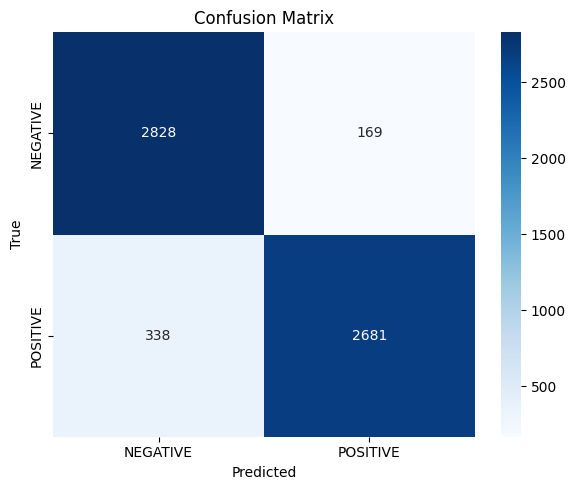


Final Accuracy: 0.9157


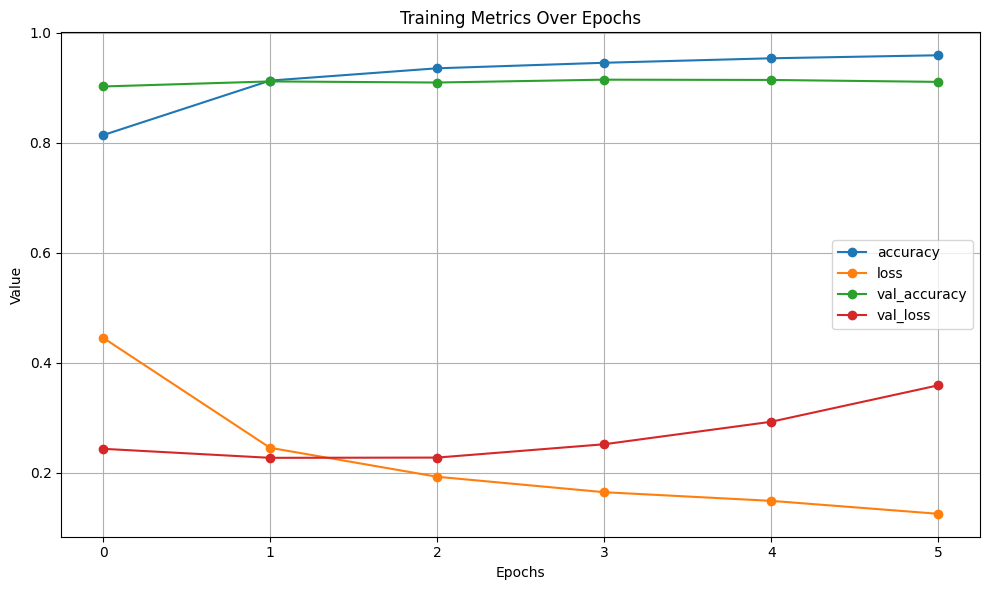

In [10]:
def build_train_emb_model(hp):
    train_emb_model = init_train_emb_model(
        max_tokens=hp.Choice("vocab_size", values= MAX_TOKENS),
        max_seq_length=MAX_LENGTH,
        embedding_dim= EMBED_DIM,
        dropout_train_emb = hp.Float("dropout_train_emb", min_value=0.1, max_value=0.5, step=0.1)
    )
    build_model(train_emb_model, hp)
    
    return train_emb_model

#Tuning
tuner_emb_model = SentimentAnalysisTuner(
    build_train_emb_model,
    project_name="lstm_sentiment"
)

tuner_emb_model.search(train_ds, val_ds)
history = tuner_emb_model.fit(train_ds, val_ds)

#Sampo migliori iperparametri
best_hp = tuner_emb_model.tuner.get_best_hyperparameters(1)[0]
print("\n=== Migliori iperparametri trovati ===")
for param in best_hp.values.keys():
    print(f"{param}: {best_hp.get(param)}")

evaluate_lstm_model(tuner_emb_model.best_model, test_ds)

plot_training_metrics(history)

## **7. Bidirectional LSTM with Glove Embedding**

Il codice seguente mostra le chiamate all'inizializzaizone e alla costruzione del modello di Rete Neurale Ricorrente con Layer Bidirezionali e con Glove Embedding

Osservando i risultati possiamo notare che il valore più alto di accuratezza sul validation set trovato tramite tuning è 93.19% con i valori riportati sotto la dicitura "Migliori Iperparametri Trovati".
Il modello presenta un recall più elevato per la classe negativa e una precision più alta per la classe positiva, riesce quindi a identificare leggermente meglio le recensioni negative, mentre quando predice “positivo” sbaglia meno. Complessivamente, l’equilibrio tra recall e precision su entrambe le classi è confermato dalle F1-score simili, senza quindi evidenti sbilanciamenti nelle predizioni.

Possiamo visualizzare la Matrice di Confusione per capire quante predizioni TruePositive o TrueNegative e quante FalsePositive o FalseNegative in modo quantitativo si sono verificate, e infine il grafico mostrante l'evoluzione di accuracy, loss, value accuracy e value loss durante le varie epoche.

Trial 15 Complete [00h 04m 25s]
val_accuracy: 0.9236297011375427

Best val_accuracy So Far: 0.9319853186607361
Total elapsed time: 01h 14m 25s
Epoch 1/30
875/875 ━━━━━━━━━━━━━━━━━━━━ 38s 40ms/step - accuracy: 0.7389 - loss: 0.5204 - val_accuracy: 0.8727 - val_loss: 0.3077
Epoch 2/30
875/875 ━━━━━━━━━━━━━━━━━━━━ 34s 39ms/step - accuracy: 0.8641 - loss: 0.3331 - val_accuracy: 0.9014 - val_loss: 0.2482
Epoch 3/30
875/875 ━━━━━━━━━━━━━━━━━━━━ 34s 39ms/step - accuracy: 0.8873 - loss: 0.2902 - val_accuracy: 0.9068 - val_loss: 0.2325
Epoch 4/30
875/875 ━━━━━━━━━━━━━━━━━━━━ 34s 39ms/step - accuracy: 0.9000 - loss: 0.2594 - val_accuracy: 0.9159 - val_loss: 0.2255
Epoch 5/30
875/875 ━━━━━━━━━━━━━━━━━━━━ 34s 39ms/step - accuracy: 0.9101 - loss: 0.2399 - val_accuracy: 0.9178 - val_loss: 0.2115
Epoch 6/30
875/875 ━━━━━━━━━━━━━━━━━━━━ 34s 39ms/step - accuracy: 0.9183 - loss: 0.2209 - val_accuracy: 0.9196 - val_loss: 0.2106
Epoch 7/30
875/875 ━━━━━━━━━━━━━━━━━━━━ 34s 39ms/step - accuracy: 0.9252 - lo

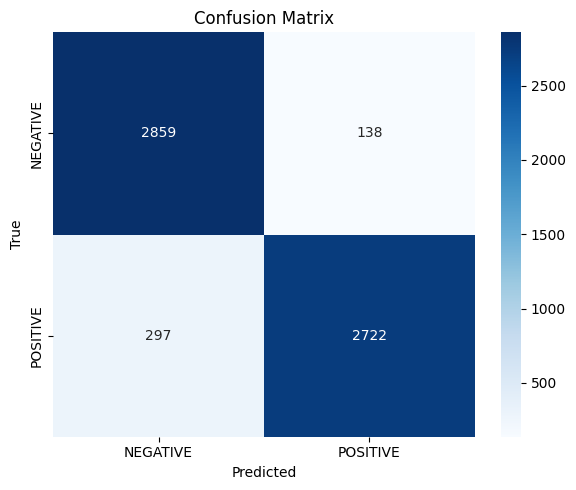


Final Accuracy: 0.9277


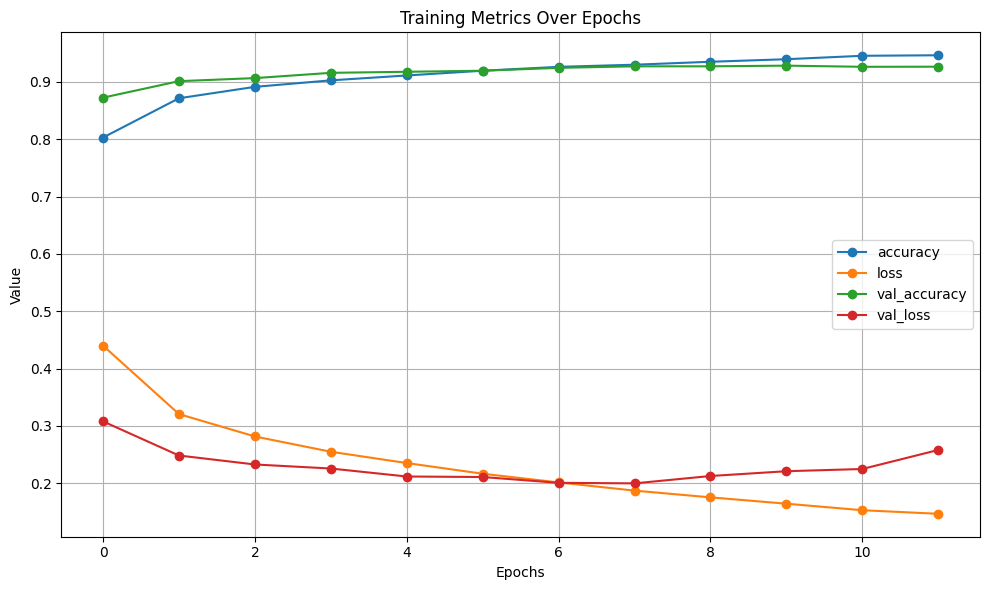

In [11]:
embedding_layer = load_glove_embeddings(GLOVE_PATH, word_index, embedding_dim=EMBEDDING_DIM)

#Tuning
model_builder = lambda hp: build_model_with_glove(hp, embedding_layer)

tuner = SentimentAnalysisTuner(
    
    build=model_builder,
    project_name="glove_sentiment_analysis",
)

train_ds = tf.data.Dataset.from_tensor_slices((X_train_pad, train_labels)).batch(32).prefetch(tf.data.AUTOTUNE)
val_ds = tf.data.Dataset.from_tensor_slices((X_val_pad, val_labels)).batch(32).prefetch(tf.data.AUTOTUNE)
test_ds = tf.data.Dataset.from_tensor_slices((X_test_pad, test_labels)).batch(32).prefetch(tf.data.AUTOTUNE)

tuner.search(train_ds, val_ds, epochs=30, patience=4)
history =tuner.fit(train_ds, val_ds, epochs=30, patience=4)

#Stampo risultait migliori tuning
best_hp = tuner.tuner.get_best_hyperparameters(1)[0]
print("\n=== Migliori iperparametri trovati ===")
for param in best_hp.values.keys():
    print(f"{param}: {best_hp.get(param)}")

evaluate_lstm_model(tuner.best_model, test_ds)

tuner.best_model.save("best_glove_model.h5")

plot_training_metrics(history)



## **8. Transformer Bert-Base-Uncased-SST-2**

Come detto precedentemente lo stato dell'arte attuale è rappresentato dai Transformers, che per completezza ho voluto sperimentare.

Il codice compatto sottostante rappresenta una banale implementazione di un modello basato su Transformer, per la precisione un Transformer pre addestrato scelto ad hoc per il compito che stiamo affrontando.

Usiamo il Transformer pre addestrato `bert-base-uncased-SST-2` assieme al Tokenizer fatto appositamente per esso per effettuare inferenza su tutto il dataset. Infatti essendo un modello pre addestrato dividere il dataset in tutte le sue sottoporzioni e aggiungere training al modello risulta essere non efficiente poiché il esso potrebbe non migliorare ciò che già conosce. Il training sul Transformers è stato comunque sperimentato ed è stato osservato come il modello desse la stessa accuratezza per ogni epoca di training indicando proprio il fatto che ciò che già conosceva non si stesse evolvendo, evitando quindi l'onerosità di calibrare in maniera pesante il training del modello pre addestrato o quella di addestrare un Transformers da zero è stata adottata la sola inferenza su tutto il dataset.

In particolare il Transformer bert-base-uncased-SST-2 è stato addestrato su corpora come BookCorpus e Wikipedia in ingelese al fine migliorare le metriche di linguistic analysis e successivamente pre tunato sul dataset `Stanford Sentiment Treebank v2` per addestrare il modello nel sentiment analysis.

Osservando i risultati possiamo notare che il valore di accuratezza è pari al 90.29%.
Il modello presenta un recall più elevato per la classe negativa e una precision più alta per la classe positiva, riesce quindi a identificare leggermente meglio le recensioni negative, mentre quando predice “positivo” sbaglia meno. Complessivamente, l’equilibrio tra recall e precision su entrambe le classi è confermato dalle F1-score simili, senza quindi evidenti sbilanciamenti nelle predizioni.

Possiamo visualizzare la Matrice di Confusione per capire quante predizioni TruePositive o TrueNegative e quante FalsePositive o FalseNegative in modo quantitativo si sono verificate.

Found 40000 files belonging to 2 classes.
1250/1250 [==============================] - 256s 201ms/step

Classification Report:

              precision    recall  f1-score   support

    NEGATIVE       0.88      0.93      0.91     20000
    POSITIVE       0.92      0.88      0.90     20000

    accuracy                           0.90     40000
   macro avg       0.90      0.90      0.90     40000
weighted avg       0.90      0.90      0.90     40000



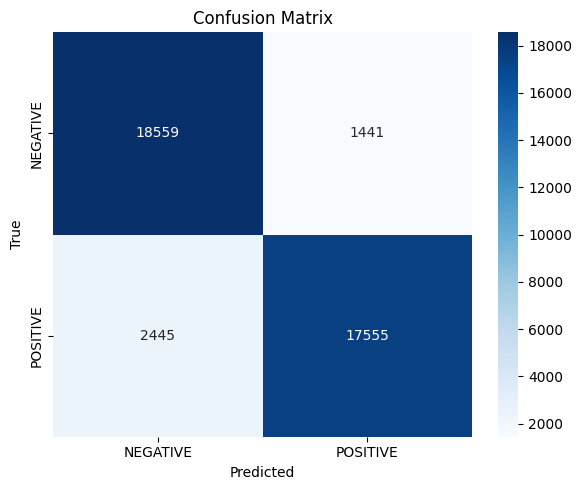


Final Accuracy: 0.9029


In [12]:
#Transformers BERT pretrained - pretuned

MAX_LENGTH = 256

# Tokenizer e modello pre-addestrato (fine-tunato su SST-2)
tokenizer = BertTokenizer.from_pretrained("textattack/bert-base-uncased-SST-2")
model = TFBertForSequenceClassification.from_pretrained("textattack/bert-base-uncased-SST-2", from_pt=True)


def evaluate_model_predictions(model, tokenizer, texts, labels, max_length=256, batch_size=32):
    # Tokenizzazione
    encodings = tokenizer(
        texts,
        truncation=True,
        padding=True,
        max_length=max_length,
        return_tensors='tf'
    )

    #Dataset TensorFlow per inferenza
    infer_ds = tf.data.Dataset.from_tensor_slices({
        "input_ids": encodings["input_ids"],
        "attention_mask": encodings["attention_mask"]
    }).batch(batch_size)

    # Inferenza
    logits = model.predict(infer_ds).logits
    probs = tf.nn.softmax(logits, axis=1).numpy()
    preds = np.argmax(probs, axis=1)

    #Report
    print("\nClassification Report:\n")
    print(classification_report(labels, preds, target_names=["NEGATIVE", "POSITIVE"]))

    #Confusion Matrix
    cm = confusion_matrix(labels, preds)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=["NEGATIVE", "POSITIVE"],
                yticklabels=["NEGATIVE", "POSITIVE"])
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title("Confusion Matrix")
    plt.tight_layout()
    plt.show()

    acc = accuracy_score(labels, preds)
    print(f"\nFinal Accuracy: {acc:.4f}")


# Funzione per estrarre testi e label da un tf.data.Dataset
def extract_texts_and_labels_for_distilbert(dataset):
    texts = []
    labels = []
    for text, label in dataset:  # già non batchato
        if isinstance(text.numpy(), bytes):
            texts.append(text.numpy().decode("utf-8"))
        else:
            texts.append(str(text.numpy()))
        labels.append(label.numpy())
    return texts, labels

# Preparazione dati per inferenza
def encode_text(texts):
    return tokenizer(texts, truncation=True, padding=True, max_length=MAX_LENGTH, return_tensors='tf')

raw_data = load_full_dataset()
texts, labels = zip(*raw_data)
encodings = encode_text(list(texts))

evaluate_model_predictions(model, tokenizer, list(texts), list(labels), max_length=MAX_LENGTH)



## **9. Inferenza su Recensioni Personali**

Il codice sottostante mostra l'infernza da parte del modello BRNN con Glove Embedding su delle recensioni scritte manualmente. 

Alcune recensioni sono state scritte appositamente per cercare di confondere la macchina durante la predizione ad esempio screditando in parte il prodotto che si sta comprando per poi descriverne i lati positivi, tipico di una recensione che riterremmo 3 stelle su Amazon.

Osservando i risultati possiamo notare come il modello abbia sbagliato una sola predizione su 10 realizzando un falso negativo con una confidenza pari a 0.01 dimostrando che il modello fosse altamente convinto della predizione svolta. Tale recensione in particolare fa parte delle recensioni considerate 3 stelle su 5 ovvero quelle che danno spesso informazioni più contrastanti o ritrattative che confondono la macchina.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 395ms/step

=== Dettaglio inferenza recensioni personalizzate ===

Recensione 1: SBAGLIATO
Testo: It should be soluble but it remains powdery in some parts, the taste is good, I would re-do it, but it leaves a bitter aftertaste not suitable for all palates
Etichetta attesa: POSITIVE
Predetta: NEGATIVE (Confidenza: 0.01)

Recensione 2: CORRETTO
Testo: After trying the strawberry fragrance I liked it so much that I ordered the others fragrances to try them too =D
Etichetta attesa: POSITIVE
Predetta: POSITIVE (Confidenza: 0.82)

Recensione 3: CORRETTO
Testo: It's decent for a pantry staple. Nothing to write home about, but it does the job. Tastes fine, and delivery was quick. I might try another brand next time just to compare.
Etichetta attesa: POSITIVE
Predetta: POSITIVE (Confidenza: 0.98)

Recensione 4: CORRETTO
Testo: These were a game changer for my meal prep routine. Everything arrived sealed, fresh, and ready to go. Healthy and convenient, just what I ne

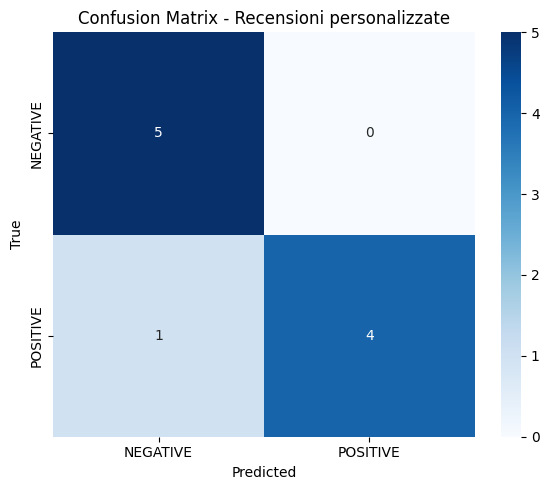

In [13]:
from IPython.core.display import display, HTML

display(HTML("<style>.output_wrapper, .output {height:auto !important; max-height:10000px;}</style>"))

#Recensioni per inferenza
recensioni_positive = [
    "It should be soluble but it remains powdery in some parts, the taste is good, I would re-do it, but it leaves a bitter aftertaste not suitable for all palates",
    "After trying the strawberry fragrance I liked it so much that I ordered the others fragrances to try them too =D",
    "It's decent for a pantry staple. Nothing to write home about, but it does the job. Tastes fine, and delivery was quick. I might try another brand next time just to compare.",
    "These were a game changer for my meal prep routine. Everything arrived sealed, fresh, and ready to go. Healthy and convenient, just what I needed :D",
    "It is an excellent alternative to industrial products, certainly not for everyone's budget given the considerable cost."
]
#Dovrebbe essere solubile ma rimane polveroso in alcune parti, il sapore è buono, lo riodinerei, ma lascia un retrogusto amaro non adatto a tutti i palati.
#Dopo aver provato la fragranza alla fragola mi è piaciuta talmente tanto che ho ordinato anche le altre per assaggiarle
#È discreto per un prodotto da dispensa. Nulla di eccezionale, ma fa il suo lavoro. Il gusto è accettabile e la consegna è stata rapida. Forse proverò un’altra marca la prossima volta, giusto per confrontare.
#Questo prodotto ha rivoluzionato la mia routine di preparazione pasti. È arrivato tutto sigillato, fresco e pronto all’uso. Sano e pratico, proprio quello che cercavo.
#È un'ottima alternativa ai prodotti industriali, certo non è per tutte le tasche dato il costo non indifferente 

recensioni_negative = [
    "the box arrived completely broken but the contents were intact, unfortunately the product was too close to the expiry date so I returned it :(",
    "They only use lab sugars now, aspartame is too strong!! I don't recommend buying it to anyone who doesn't want to have a stomach ache that same evening >=(",
    "After reading all the great reviews, I expected better!!! The flavor was bland and the texture was off. It is edible, but not enjoyable!",
    "The product tastes okay, but it's not what I was expecting. The texture isn't great, it's a bit too rubbery and not very fresh. I probably won't buy it again =/",
    "It arrived completely rancid, only one day of shipping and it's already like this!! This means it was already moldy before shipping, this is unacceptable!!!!"
]
#la scatola è arrivata tutta rotta ma il contenuto era intatto, purtroppo il prodotto era eccessivamente vicino alla data di scadenza quindi ho fatto il reso
#Ormai usano solo zuccheri di laboratorio, l'aspartame si sente in maniera esagerata. Sconsiglio l'acquisto a chiunque non voglia avere un mal di pancia la sera stessa
#Dopo tutte le recensioni entusiaste, mi aspettavo molto di più. Il sapore era insipido e la consistenza sgradevole. Comestibile, ma per nulla soddisfacente.
#Il prodotto ha un sapore abbastanza buono, ma non è quello che mi aspettavo. La consistenza non è delle migliori, sembra un po' troppo gommoso e non molto fresco. Probabilmente non lo ricomprerò.
#È arrivato completamente rancido, solo un giorno di spedizione ed è già così!! Questo vuol dire che era già ammuffita prima della spedizione, questa cosa è inaccettabile!!!!



#Labeling recensioni
texts = recensioni_positive + recensioni_negative
labels = [1] * len(recensioni_positive) + [0] * len(recensioni_negative)

#tokenize e padding
sequences = texts_to_sequences(texts, word_index)
padded_sequences = tf.keras.preprocessing.sequence.pad_sequences(sequences, maxlen=MAX_LENGTH, padding='post')

#Carico modello pre salvato con migliori iperparametri, lstm con embedding Glove
model = load_model("best_glove_model.h5")

#Inferenza
probs = model.predict(padded_sequences).flatten()
preds = (probs > 0.5).astype(int)

#Risultati
print("\n=== Dettaglio inferenza recensioni personalizzate ===")
for i, (text, true_label, pred_label, prob) in enumerate(zip(texts, labels, preds, probs)):
    status = "CORRETTO" if true_label == pred_label else "SBAGLIATO"
    label_name = {0: "NEGATIVE", 1: "POSITIVE"}
    print(f"\nRecensione {i+1}: {status}")
    print(f"Testo: {text}")
    print(f"Etichetta attesa: {label_name[true_label]}")
    print(f"Predetta: {label_name[pred_label]} (Confidenza: {prob:.2f})")

print("\n=== Classification Report su recensioni personalizzate ===")
print(classification_report(labels, preds, target_names=["NEGATIVE", "POSITIVE"]))

cm = confusion_matrix(labels, preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["NEGATIVE", "POSITIVE"],
            yticklabels=["NEGATIVE", "POSITIVE"])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix - Recensioni personalizzate")
plt.tight_layout()
plt.show()


## **10. Conclusioni**

Nel complesso tutti i modelli sviluppati sembrano avere accuratezza simile.

La soluzione compatta di Regressione Logistica ottiene ottimi risultati per la sua natura, dati soprattutto dall'uso del vettorizzatore TF-IDF che permette una valorizzazione della punteggiatura non indifferente.

La BRNN con Embedding addestrabile ottiene risultati molto simili al modello di Regressione Logistica sviluppato, probabilmente potrebbe essere migliorato con un pre-processamente più approfondito che valorizzi la punteggiatura, invece di rimuoverla, una gamma di iperparametri sui quale fare tuning più ampia e con un numero di trial per il tuning che permetta di migliorare il RandomSearch spaziando tra più valori per ogni parametro.

La BRNN con Glove Embedding è il modello che ottiene il risultato più alto, sicuramente anche grazie all'ottima affinità tra pre-processing e il layer di Glove che comunicano con una coverage altissima.

La soluzione compatta di Transformers bert-base-uncased-SST-2 nonostante rappresenti lo stato dell'arte ha ottenuto il risultato più basso rispetto agli altri modelli sviluppati, ciò è molto probabilmente dato dal fatto che il Transformer usato nonostante trainato per il sentiment analisys bianrio non abbia un'affinità ad hoc con il dataset sottoposto. Una soluzione a ciò è la costruzione di un modello di Transformer che esegue il training test e validation sul dataset sottoposto con apposita divisione affinché questo possa adattarsi appositamente alla situazione di sentiment analisys specifica per il nostro task, purtroppo però questa soluzione è la più onerosa soprattutto se si considera la necessita di eseguire tuning.